# SHapley Additive exPlanations

**Purpose**: Define what features were most and least important for machnine learning models reasoning

**Datasets**:
- 32 features $\times$ 3 labels (multi-label classification)

**Models**:

## Setup and Imports

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

from src.utils import load_latest_dataset, print_dataset_schema

In [ ]:
plt.rcParams["figure.figsize"] = (8, 6)
plt.rcParams["font.size"] = 11
plt.rcParams["savefig.format"] = "pdf"
plt.rcParams["savefig.bbox"] = "tight"
plt.rcParams["savefig.dpi"] = 300

### Output files directories creation

In [ ]:
artifacts_dir = Path("artifacts")
shap_dir = artifacts_dir / "shap"
shap_dir.mkdir(parents=True, exist_ok=True)

## Data Loading and Validation

In [3]:
df, manifest, version_path = load_latest_dataset(data_dir="../data/processed")


Dataset loaded: 1476 records
  Version: 1.0.0
  Created: 2026-03-28T12:20:08.802163+00:00
  Git commit: 1dad8988


In [4]:
label_cols = [
    "has_pyproject_toml",
    "has_dockerfile",
    "has_github_actions",
    "has_tox_ini",
    "has_conda_env_file",
    "has_docker_compose",
    "has_precommit_config",
    "has_setup_py",
    "has_requirements_txt",
    "has_makefile",
]

schema = print_dataset_schema(df, label_cols)


id_col = schema["id_col"]
label_cols = schema["label_cols"]
feature_cols = schema["feature_cols"]

Dataset Schema:
  Total columns: 43
  Identifier: 1 (repo_url)
  Features: 32
  Labels: 10


### SHAP Setup and Model Training

In [5]:
X = df[feature_cols]
y = df[label_cols]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=90, stratify=y["has_pyproject_toml"]
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Training set: 1180 samples
Test set: 296 samples


### SHAP Values Computation

In [6]:
label_prevalence = y_train.sum().sort_values(ascending=False)
labels = label_prevalence.head(3).index.tolist()

print("Analyzing top 3 labels:")
for label in labels:
    prevalence = label_prevalence[label] / len(y_train) * 100
    print(f"  {label}: {label_prevalence[label]} samples ({prevalence:.1f}%)")

models = {}
explainers = {}
shap_values = {}

for label in labels:
    print(f"\nTraining model for {label}...")

    rf = RandomForestClassifier(
        n_estimators=100, max_depth=10, random_state=90, n_jobs=-1
    )
    rf.fit(X_train, y_train[label])

    train_acc = rf.score(X_train, y_train[label])
    test_acc = rf.score(X_test, y_test[label])
    print(f"  Train accuracy: {train_acc:.3f}")
    print(f"  Test accuracy: {test_acc:.3f}")

    explainer = shap.TreeExplainer(rf)
    shap_vals = explainer(X_train)

    if len(shap_vals.values.shape) == 3:
        shap_vals.values = shap_vals.values[:, :, 1]
        shap_vals.base_values = shap_vals.base_values[:, 1]
    models[label] = rf
    explainers[label] = explainer
    shap_values[label] = shap_vals

Analyzing top 3 labels:
  has_github_actions: 947 samples (80.3%)
  has_pyproject_toml: 786 samples (66.6%)
  has_dockerfile: 516 samples (43.7%)

Training model for has_github_actions...
  Train accuracy: 0.999
  Test accuracy: 0.963

Training model for has_pyproject_toml...
  Train accuracy: 0.984
  Test accuracy: 0.909

Training model for has_dockerfile...
  Train accuracy: 0.998
  Test accuracy: 0.868


### SHAP Summary Plots

SHAP Analysis: has_github_actions


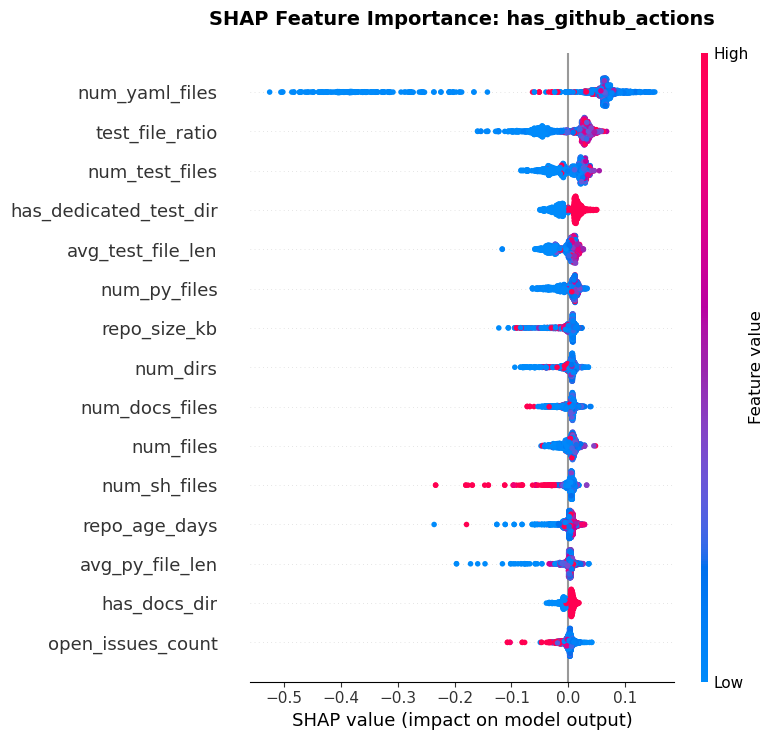

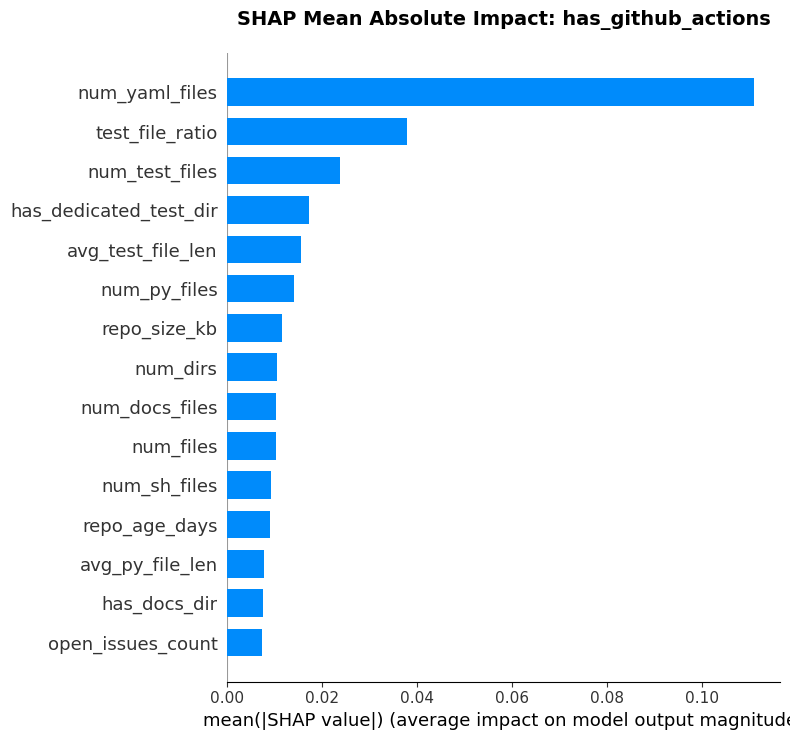

SHAP Analysis: has_pyproject_toml


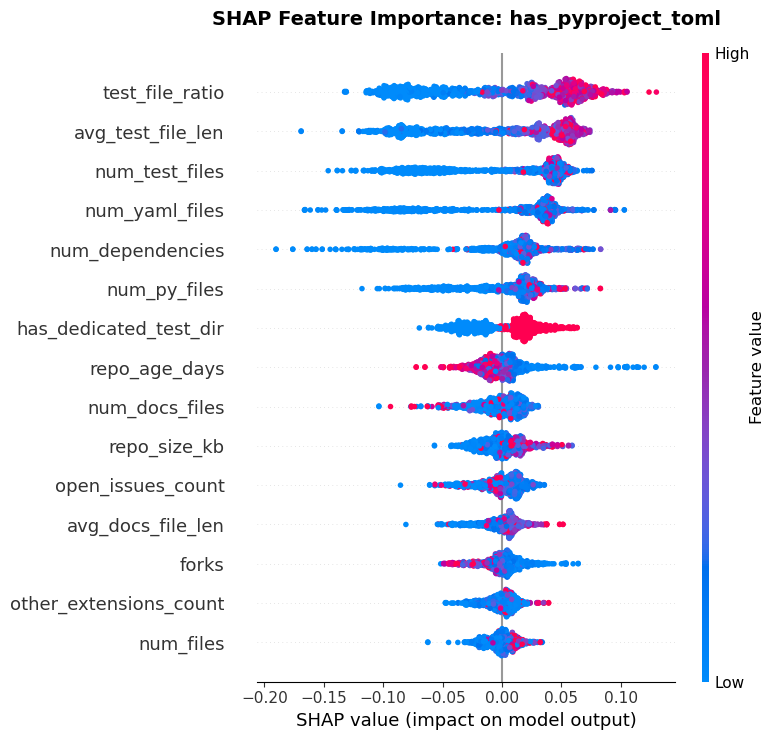

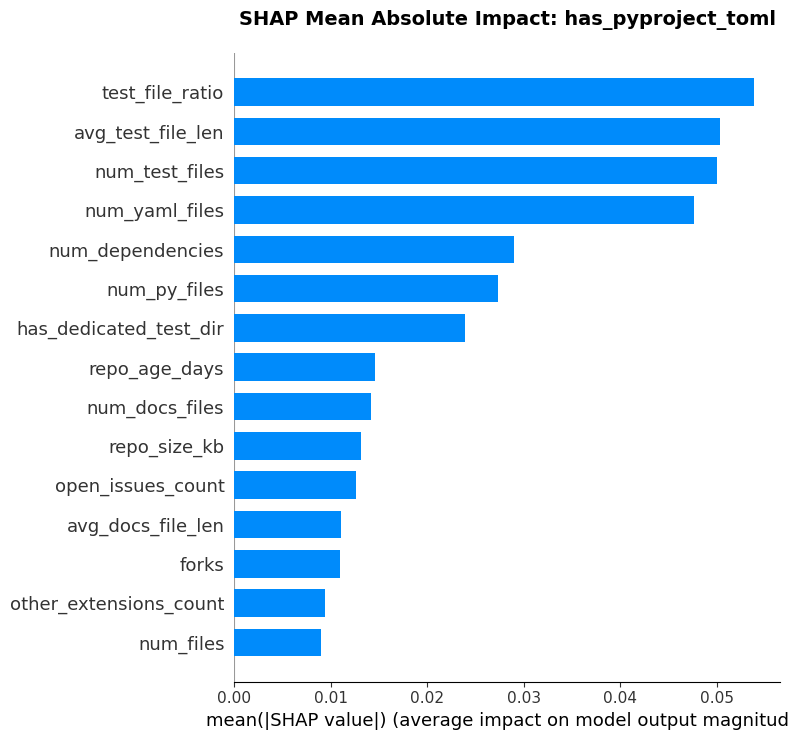

SHAP Analysis: has_dockerfile


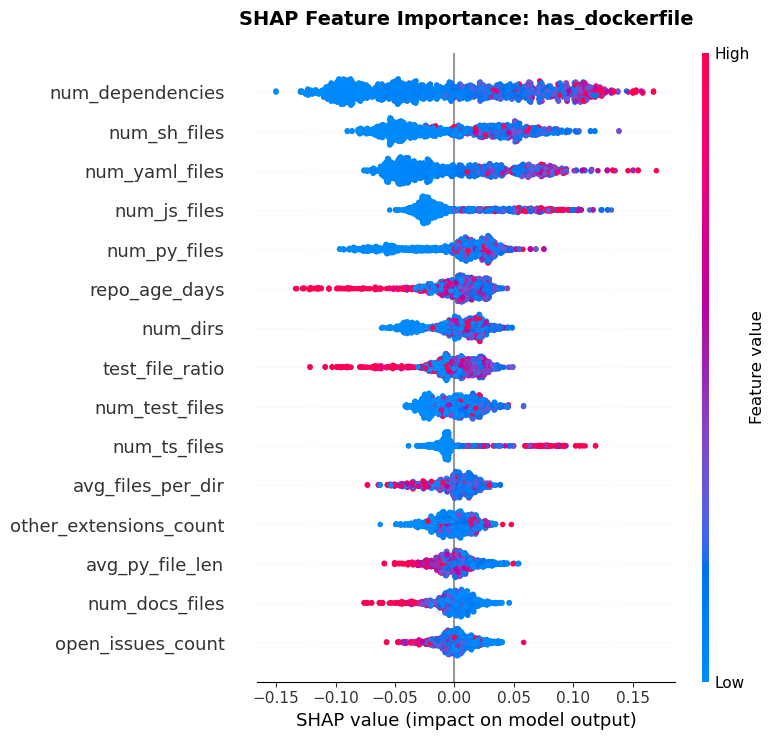

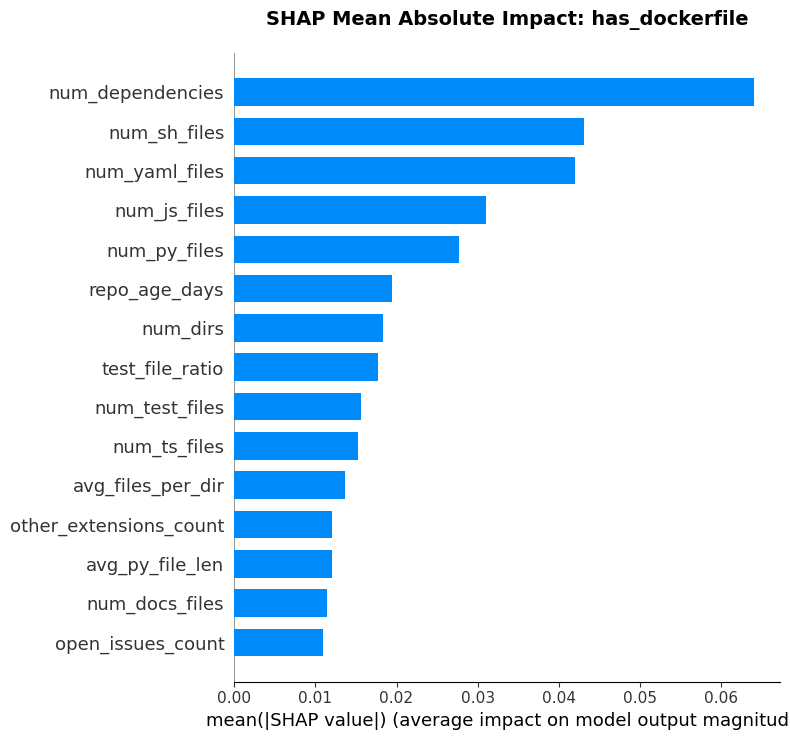

In [7]:
for label in labels:
    print(f"SHAP Analysis: {label}")

    fig, ax = plt.subplots(figsize=(10, 8))
    shap.summary_plot(shap_values[label], X_train, max_display=15, show=False)
    plt.title(
        f"SHAP Feature Importance: {label}", fontsize=14, fontweight="bold", pad=20
    )
    plt.tight_layout()
    plt.savefig(
        shap_dir / f"shap_summary_{label}.pdf", format="pdf", bbox_inches="tight"
    )
    plt.show()

    fig, ax = plt.subplots(figsize=(10, 8))
    shap.summary_plot(
        shap_values[label], X_train, plot_type="bar", max_display=15, show=False
    )
    plt.title(
        f"SHAP Mean Absolute Impact: {label}", fontsize=14, fontweight="bold", pad=20
    )
    plt.tight_layout()
    plt.savefig(shap_dir / f"shap_bar_{label}.pdf", format="pdf", bbox_inches="tight")
    plt.show()

### Top SHAP Features per Label

Extract and display top features by mean absolute SHAP value.

In [8]:
print("Top 10 Features by Mean Absolute SHAP Value:")

for label in labels:
    print(f"\n{label}:")

    mean_abs_shap = np.abs(shap_values[label].values).mean(axis=0)

    shap_importance = pd.DataFrame(
        {"feature": feature_cols, "mean_abs_shap": mean_abs_shap}
    ).sort_values("mean_abs_shap", ascending=False)

    for rank, row in enumerate(shap_importance.head(10).itertuples(), 1):
        print(f"  {rank:2d}. {row.feature:30s}  {row.mean_abs_shap:.4f}")

    shap_importance.to_csv(shap_dir / f"shap_importance_{label}.csv", index=False)

Top 10 Features by Mean Absolute SHAP Value:

has_github_actions:
   1. num_yaml_files                  0.1109
   2. test_file_ratio                 0.0378
   3. num_test_files                  0.0238
   4. has_dedicated_test_dir          0.0171
   5. avg_test_file_len               0.0155
   6. num_py_files                    0.0141
   7. repo_size_kb                    0.0114
   8. num_dirs                        0.0104
   9. num_docs_files                  0.0103
  10. num_files                       0.0103

has_pyproject_toml:
   1. test_file_ratio                 0.0538
   2. avg_test_file_len               0.0504
   3. num_test_files                  0.0500
   4. num_yaml_files                  0.0477
   5. num_dependencies                0.0290
   6. num_py_files                    0.0273
   7. has_dedicated_test_dir          0.0239
   8. repo_age_days                   0.0146
   9. num_docs_files                  0.0142
  10. repo_size_kb                    0.0131

has_dockerfi